### Inrtra3 Marouane Bouriel

In [42]:
import pandas as pd
import numpy as np
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns

## 1- Charger et explorer les données

In [43]:
# Charger le dataset
df = pd.read_csv('tips.txt', sep=';', decimal=',')

df['TIP'] = pd.to_numeric(df['TIP'], errors='coerce')
df['TOTBILL'] = pd.to_numeric(df['TOTBILL'], errors='coerce')
df['SIZE'] = pd.to_numeric(df['SIZE'], errors='coerce')
df['SEX'] = pd.to_numeric(df['SEX'], errors='coerce')
df['SMOKER'] = pd.to_numeric(df['SMOKER'], errors='coerce')
df['TIME'] = pd.to_numeric(df['TIME'], errors='coerce')

print("\nDimensions du dataset:", df.shape)
print(f"Nombre de lignes (transactions): {df.shape[0]}")
print(f"Nombre de colonnes (variables): {df.shape[1]}")

print("\n" + "-" * 80)
print("PREMIÈRES LIGNES DU DATASET:")
print("-" * 80)
print(df.head(10))

print("\n" + "-" * 80)
print("INFORMATIONS SUR LES COLONNES:")
print("-" * 80)
print(df.info())

print("\n" + "-" * 80)
print("STATISTIQUES DESCRIPTIVES:")
print("-" * 80)
print(df.describe())


Dimensions du dataset: (244, 8)
Nombre de lignes (transactions): 244
Nombre de colonnes (variables): 8

--------------------------------------------------------------------------------
PREMIÈRES LIGNES DU DATASET:
--------------------------------------------------------------------------------
   IDEN  TOTBILL   TIP  SEX  SMOKER  DAY  TIME  SIZE
0  R001    16.99  1.01    1       0    6     1     2
1  R002    10.34  1.66    0       0    6     1     3
2  R003    21.01  3.50    0       0    6     1     3
3  R004    23.68  3.31    0       0    6     1     2
4  R005    24.59  3.61    1       0    6     1     4
5  R006    25.29  4.71    0       0    6     1     4
6  R007     8.77  2.00    0       0    6     1     2
7  R008    26.88  3.12    0       0    6     1     4
8  R009    15.04  1.96    0       0    6     1     2
9  R010    14.78  3.23    0       0    6     1     2

--------------------------------------------------------------------------------
INFORMATIONS SUR LES COLONNES:
--------

### 2- Vérification de types des variables en binaires

In [44]:
print(" VÉRIFIER LES VARIABLES BINAIRES")
print("=" * 80)

# Variables à vérifier (TOUTES les variables)
variables = ['SEX', 'SMOKER', 'TIME', 'TIP', 'SIZE']

for var in variables:
    valeurs = sorted(df[var].unique())
    print(f"\n{var}: {valeurs}")

 VÉRIFIER LES VARIABLES BINAIRES

SEX: [np.int64(0), np.int64(1)]

SMOKER: [np.int64(0), np.int64(1)]

TIME: [np.int64(0), np.int64(1)]

TIP: [np.float64(0.0), np.float64(1.0), np.float64(1.01), np.float64(1.1), np.float64(1.17), np.float64(1.25), np.float64(1.32), np.float64(1.36), np.float64(1.44), np.float64(1.45), np.float64(1.47), np.float64(1.48), np.float64(1.5), np.float64(1.56), np.float64(1.57), np.float64(1.58), np.float64(1.61), np.float64(1.63), np.float64(1.64), np.float64(1.66), np.float64(1.67), np.float64(1.68), np.float64(1.71), np.float64(1.73), np.float64(1.75), np.float64(1.76), np.float64(1.8), np.float64(1.83), np.float64(1.92), np.float64(1.96), np.float64(1.97), np.float64(1.98), np.float64(2.0), np.float64(2.01), np.float64(2.02), np.float64(2.03), np.float64(2.05), np.float64(2.09), np.float64(2.18), np.float64(2.2), np.float64(2.23), np.float64(2.24), np.float64(2.3), np.float64(2.31), np.float64(2.34), np.float64(2.45), np.float64(2.47), np.float64(2.5), np

- SIZE et TIP ne sont pas binaires

### 3- Transformation des variables en binaires

In [45]:
print("\n TRANSFORMER TIP EN POURCENTAGE ET BINARISER")
print("=" * 80)

# Calculer le pourcentage de pourboire
df['TIP_PERCENT'] = (df['TIP'] / df['TOTBILL']) * 100

print("\nExemples de transformation:")
print(df.head(10))

print("\nStatistiques du pourcentage de pourboire:")
print(f"  Minimum: {df['TIP_PERCENT'].min():.2f}%")
print(f"  Maximum: {df['TIP_PERCENT'].max():.2f}%")
print(f"  Moyenne: {df['TIP_PERCENT'].mean():.2f}%")
print(f"  Médiane: {df['TIP_PERCENT'].median():.2f}%")

# Binariser à la médiane
# Si pourcentage > médiane → TIP = 1 (pourboire élevé)
mediane_tip_percent = df['TIP_PERCENT'].median()
print(f"\nMédiane: {mediane_tip_percent:.2f}%")

df['TIP'] = (df['TIP_PERCENT'] > mediane_tip_percent).astype(int)

print(f"\nAprès binarisation:")
print(f"  TIP = 0 (faible): {(df['TIP'] == 0).sum()} transactions")
print(f"  TIP = 1 (élevé): {(df['TIP'] == 1).sum()} transactions")
print(df.head(10))


 TRANSFORMER TIP EN POURCENTAGE ET BINARISER

Exemples de transformation:
   IDEN  TOTBILL   TIP  SEX  SMOKER  DAY  TIME  SIZE  TIP_PERCENT
0  R001    16.99  1.01    1       0    6     1     2     5.944673
1  R002    10.34  1.66    0       0    6     1     3    16.054159
2  R003    21.01  3.50    0       0    6     1     3    16.658734
3  R004    23.68  3.31    0       0    6     1     2    13.978041
4  R005    24.59  3.61    1       0    6     1     4    14.680765
5  R006    25.29  4.71    0       0    6     1     4    18.623962
6  R007     8.77  2.00    0       0    6     1     2    22.805017
7  R008    26.88  3.12    0       0    6     1     4    11.607143
8  R009    15.04  1.96    0       0    6     1     2    13.031915
9  R010    14.78  3.23    0       0    6     1     2    21.853857

Statistiques du pourcentage de pourboire:
  Minimum: 0.00%
  Maximum: 71.03%
  Moyenne: 16.00%
  Médiane: 15.41%

Médiane: 15.41%

Après binarisation:
  TIP = 0 (faible): 122 transactions
  TIP = 1 

In [46]:
print("\n TRANSFORMER SIZE EN VARIABLE BINAIRE")
print("=" * 80)

print("\nDistribution de SIZE:")
print(df['SIZE'].value_counts().sort_index())

# Créer UNE SEULE variable binaire pour SIZE pour en pas avoir de redandance

df['SIZE_Small'] = (df['SIZE'] <= 2).astype(int) # 1 pour petit groupe, 0 pour grand groupe

print(f"\nNouvelle variable créée:")
print(f"  SIZE_Small: {df['SIZE_Small'].sum()} cas")

print(f"\nVérification:")
print(f"  SIZE_Small valeurs uniques: {sorted(df['SIZE_Small'].unique())}")

print("\nSignification:")
print(f"  SIZE_Small=1 (petit groupe, ≤2 personnes): {(df['SIZE_Small']==1).sum()} cas")
print(f"  SIZE_Small=0 (grand groupe, ≥3 personnes): {(df['SIZE_Small']==0).sum()} cas")

print("\n SIZE est maintenant représentée par 1 variable binaire (pas de redondance)")



 TRANSFORMER SIZE EN VARIABLE BINAIRE

Distribution de SIZE:
SIZE
1      4
2    156
3     38
4     37
5      5
6      4
Name: count, dtype: int64

Nouvelle variable créée:
  SIZE_Small: 160 cas

Vérification:
  SIZE_Small valeurs uniques: [np.int64(0), np.int64(1)]

Signification:
  SIZE_Small=1 (petit groupe, ≤2 personnes): 160 cas
  SIZE_Small=0 (grand groupe, ≥3 personnes): 84 cas

 SIZE est maintenant représentée par 1 variable binaire (pas de redondance)


In [51]:
print("\n CRÉER LE DATASET DE TRANSACTIONS")
print("=" * 80)

# Préparer les données

df_prep = df[['SEX', 'SMOKER', 'TIME', 'SIZE_Small', 'TIP']].copy()
print(f"Colonnes sélectionnées: {df_prep.columns.tolist()}")

# Convertir les variables en variables binaires
print("\n--- Binarisation avec get_dummies() ---")
transactions = pd.get_dummies(
    df_prep,
    columns=['SEX', 'SMOKER', 'TIME'],
    prefix=['SEX', 'SMOKER', 'TIME'],
    drop_first=True,
    dtype=int
)

print("\nColonnes après get_dummies():")
print(transactions.columns.tolist())

# Renommer les colonnes
print("\n--- Renommage des colonnes ---")
rename_dict = {
    'SEX_1': 'SEX_Male',
    'SMOKER_1': 'SMOKER_Yes',
    'TIME_1': 'TIME_Dinner',
    'SIZE_Small': 'SIZE_Small',
    'TIP': 'TIP_High'
}

transactions = transactions.rename(columns=rename_dict)
print(transactions.head(10))

# RÉSULTATS FINAUX 
print("\n" + "=" * 80)
print("RÉSUMÉ FINAL DU DATASET DE TRANSACTIONS")
print("=" * 80)

print(f"\nDimensions du dataset:")
print(f"  Nombre de transactions: {len(transactions)}")
print(f"  Nombre d'items (colonnes): {len(transactions.columns)}")


 CRÉER LE DATASET DE TRANSACTIONS
Colonnes sélectionnées: ['SEX', 'SMOKER', 'TIME', 'SIZE_Small', 'TIP']

--- Binarisation avec get_dummies() ---

Colonnes après get_dummies():
['SIZE_Small', 'TIP', 'SEX_1', 'SMOKER_1', 'TIME_1']

--- Renommage des colonnes ---
   SIZE_Small  TIP_High  SEX_Male  SMOKER_Yes  TIME_Dinner
0           1         0         1           0            1
1           0         1         0           0            1
2           0         1         0           0            1
3           1         0         0           0            1
4           0         0         1           0            1
5           0         1         0           0            1
6           1         1         0           0            1
7           0         0         0           0            1
8           1         0         0           0            1
9           1         1         0           0            1

RÉSUMÉ FINAL DU DATASET DE TRANSACTIONS

Dimensions du dataset:
  Nombre de transaction


1. GÉNÉRATION DES FREQUENT ITEMSETS (Support ≥ 3%)
--------------------------------------------------------------------------------
 31 itemsets fréquents générés
 Support minimum: 3.0%

--- GRAPHIQUE: Distribution des Itemsets par Taille ---


C:\Users\bouma12\AppData\Roaming\Python\Python312\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


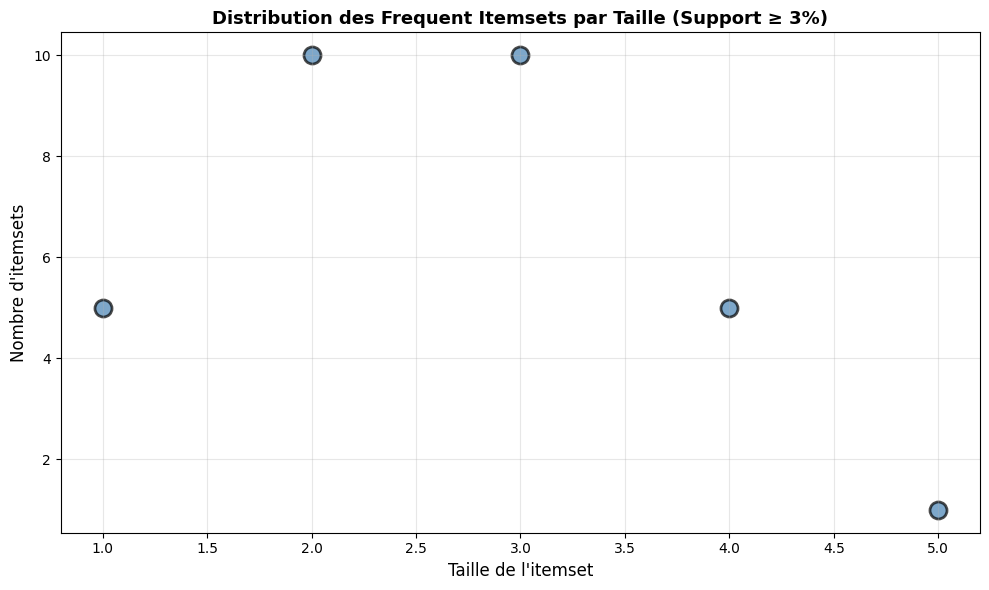

In [71]:
from mlxtend.frequent_patterns import apriori, association_rules

print("\n1. GÉNÉRATION DES FREQUENT ITEMSETS (Support ≥ 3%)")
print("-" * 80)

min_support = 0.03
frequent_itemsets = apriori(transactions, min_support=min_support, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False)

print(f" {len(frequent_itemsets)} itemsets fréquents générés")
print(f" Support minimum: {min_support*100}%")

# --- GRAPHIQUE  ---
print("\n--- GRAPHIQUE: Distribution des Itemsets par Taille ---")

# Créer la distribution des itemsets par taille
itemsets_by_size = frequent_itemsets['itemsets'].apply(lambda x: len(x)).value_counts().sort_index()

# Créer le scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(itemsets_by_size.index, itemsets_by_size.values, s=150, alpha=0.7, color='steelblue', edgecolors='black', linewidth=2)
plt.xlabel("Taille de l'itemset", fontsize=12)
plt.ylabel("Nombre d'itemsets", fontsize=12)
plt.title("Distribution des Frequent Itemsets par Taille (Support ≥ 3%)", fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




In [73]:
print("\n2. NOMBRE DE FREQUENT ITEMSETS À UTILISER")
print("-" * 80)

print("\nRépartition par taille:")
for size, count in itemsets_by_size.items():
    print(f"  Itemsets de taille {size}: {count}")

print(f"\n✓ Total: {len(frequent_itemsets)} itemsets fréquents")


2. NOMBRE DE FREQUENT ITEMSETS À UTILISER
--------------------------------------------------------------------------------

Répartition par taille:
  Itemsets de taille 1: 5
  Itemsets de taille 2: 10
  Itemsets de taille 3: 10
  Itemsets de taille 4: 5
  Itemsets de taille 5: 1

✓ Total: 31 itemsets fréquents


In [75]:
print("\n3. GÉNÉRER LES RÈGLES D'ASSOCIATIONS")
print("-" * 80)

all_rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.0)

print(f"\n Nombre total de règles générées: {len(all_rules)}")

tip_rules = all_rules[all_rules['consequents'].astype(str).str.contains('TIP_High')]
print(f" Nombre de règles avec TIP_High comme conséquent: {len(tip_rules)}")


3. GÉNÉRER LES RÈGLES D'ASSOCIATIONS
--------------------------------------------------------------------------------

 Nombre total de règles générées: 180
 Nombre de règles avec TIP_High comme conséquent: 65


In [81]:
print("\n4. RÈGLES AVEC CONFIDENCE > 50%")
print("-" * 80)

print("\n4a. Pourquoi confidence > 50%?")
print("- Confidence > 50% signifie: Si l'antécédent est vrai, alors le conséquent est vrai dans plus de 50% des cas")
print("- C'est un seuil minimum pour avoir une règle fiable")


4. RÈGLES AVEC CONFIDENCE > 50%
--------------------------------------------------------------------------------

4a. Pourquoi confidence > 50%?
- Confidence > 50% signifie: Si l'antécédent est vrai, alors le conséquent est vrai dans plus de 50% des cas
- C'est un seuil minimum pour avoir une règle fiable


In [ ]:
print("\n4b. GÉNÉRER CES RÈGLES AVEC COMME CONSÉQUENT « TIP »")
print("=" * 80)

# Filtrer les règles
rules_tip_confident = all_rules[
    (all_rules['confidence'] > 0.50) & 
    (all_rules['consequents'].astype(str).str.contains('TIP_High'))
]

rules_tip_confident = rules_tip_confident.sort_values('confidence', ascending=False)

print(f" Filtre appliqué:")
print(f"  • Confidence > 50%")
print(f"  • Conséquent = TIP_High")

print(f"\nNOMBRE DE RÈGLES TROUVÉES: {len(rules_tip_confident)}")



4b. GÉNÉRER CES RÈGLES AVEC COMME CONSÉQUENT « TIP »
 Filtre appliqué:
  • Confidence > 50%
  • Conséquent = TIP_High

NOMBRE DE RÈGLES TROUVÉES: 13

 STATISTIQUES:
  • Nombre total de règles: 13
  • Confidence moyenne: 58.12%
  • Confidence minimum: 51.02%
  • Confidence maximum: 72.22%


In [86]:

print("\n4c. QU'EN DÉDUISEZ-VOUS?")
print("=" * 80)
print(f"\n STATISTIQUES:")
print(f"  • Nombre total de règles: {len(rules_tip_confident)}")
print(f"  • Confidence moyenne: {rules_tip_confident['confidence'].mean():.2%}")
print(f"  • Confidence minimum: {rules_tip_confident['confidence'].min():.2%}")
print(f"  • Confidence maximum: {rules_tip_confident['confidence'].max():.2%}")



4c. QU'EN DÉDUISEZ-VOUS?

 STATISTIQUES:
  • Nombre total de règles: 13
  • Confidence moyenne: 58.12%
  • Confidence minimum: 51.02%
  • Confidence maximum: 72.22%


In [89]:
print("\n5. CONCLUSION POUR LE RESTAURATEUR")
print("=" * 80)
if len(rules_tip_confident) > 0:
    print(f"\n✓ INTERPRÉTATION ET DÉDUCTIONS:")
    print(f"\n  1. {len(rules_tip_confident)} profils de clients donnent SYSTÉMATIQUEMENT")
    print(f"     des pourboires élevés (probabilité > 50%)")
    
    print(f"\n  2. Confiance moyenne de {rules_tip_confident['confidence'].mean():.0%}:")
    print(f"     Les règles trouvées sont FIABLES et REPRODUCTIBLES")
    
    print(f"\n  3. Profils identifiés:")
    for i, (idx, row) in enumerate(rules_tip_confident.iterrows(), 1):
        antecedent = ", ".join(list(row['antecedents']))
        confidence = row['confidence']
        lift = row['lift']
        print(f"Profil {i}: {antecedent}")
        print(f"Probabilité pourboire élevé: {confidence:.0%}")
        print(f"{lift:.2f}x plus probable que la moyenne\n")
    
    print(f"  4. CONCLUSION:")
    print(f"     Ces {len(rules_tip_confident)} règles permettent de prédire")
    print(f"     avec confiance quels clients donneront des pourboires élevés")

else:
    print(f"\nAucune règle fiable n'a été trouvée")



5. CONCLUSION POUR LE RESTAURATEUR

✓ INTERPRÉTATION ET DÉDUCTIONS:

  1. 13 profils de clients donnent SYSTÉMATIQUEMENT
     des pourboires élevés (probabilité > 50%)

  2. Confiance moyenne de 58%:
     Les règles trouvées sont FIABLES et REPRODUCTIBLES

  3. Profils identifiés:
Profil 1: SEX_Male, TIME_Dinner, SIZE_Small, SMOKER_Yes
Probabilité pourboire élevé: 72%
1.44x plus probable que la moyenne

Profil 2: SEX_Male, SMOKER_Yes, TIME_Dinner
Probabilité pourboire élevé: 70%
1.39x plus probable que la moyenne

Profil 3: SEX_Male, SMOKER_Yes, SIZE_Small
Probabilité pourboire élevé: 65%
1.31x plus probable que la moyenne

Profil 4: SEX_Male, SMOKER_Yes
Probabilité pourboire élevé: 64%
1.27x plus probable que la moyenne

Profil 5: SEX_Male, TIME_Dinner, SIZE_Small
Probabilité pourboire élevé: 59%
1.18x plus probable que la moyenne

Profil 6: SEX_Male, TIME_Dinner, SMOKER_Yes
Probabilité pourboire élevé: 57%
1.64x plus probable que la moyenne

Profil 7: SEX_Male, TIME_Dinner
Probabili